In [1]:
### Model Development and Comparative Evaluation
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from xgboost import XGBClassifier

In [2]:
DATA_PATH = Path("data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [3]:
###define target and predictors
TARGET = "Diabetes_binary"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (70692, 21)
y shape: (70692,)

Target distribution:
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


In [4]:
##Create one fixed stratified train/test split
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining target proportions:")
print(y_train.value_counts(normalize=True))

print("\nTest target proportions:")
print(y_test.value_counts(normalize=True))

Training shape: (56553, 21)
Test shape: (14139, 21)

Training target proportions:
Diabetes_binary
1.0    0.500009
0.0    0.499991
Name: proportion, dtype: float64

Test target proportions:
Diabetes_binary
0.0    0.500035
1.0    0.499965
Name: proportion, dtype: float64


In [5]:
train_test_overlap = set(X_train.index).intersection(set(X_test.index))

print("Number of overlapping row indices:", len(train_test_overlap))

Number of overlapping row indices: 0


In [6]:
###Define variable groups
binary_cols = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost",
    "DiffWalk", "Sex"
]

ordinal_cols = [
    "GenHlth", "Age", "Education", "Income"
]

count_cols = [
    "MentHlth", "PhysHlth"
]

numeric_cols = [
    "BMI"
]

In [7]:
all_defined_features = (
    binary_cols +
    ordinal_cols +
    count_cols +
    numeric_cols
)

print("Defined predictors:", len(all_defined_features))
print("Actual predictors:", X.shape[1])

print("Missing from groups:", set(X.columns) - set(all_defined_features))
print("Unexpected in groups:", set(all_defined_features) - set(X.columns))

Defined predictors: 21
Actual predictors: 21
Missing from groups: set()
Unexpected in groups: set()


In [8]:
###Create the Logistic Regression preprocessor:
scaled_cols = numeric_cols + ordinal_cols + count_cols

logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("scaled", StandardScaler(), scaled_cols),
        ("binary", "passthrough", binary_cols)
    ],
    remainder="drop"
)

In [9]:
##Define baseline models
logistic_model = Pipeline([
    ("preprocessor", logistic_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

decision_tree_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgboost_model = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=-1
)

In [10]:
#######common 5 fold CV design
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [11]:
###define common metrics
scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

In [12]:
###Run baseline cross-validation
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgboost_model
}

In [13]:
baseline_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    baseline_results.append({
        "Model": name,
        "ROC_AUC_mean": scores["test_roc_auc"].mean(),
        "ROC_AUC_std": scores["test_roc_auc"].std(),
        "Accuracy_mean": scores["test_accuracy"].mean(),
        "Precision_mean": scores["test_precision"].mean(),
        "Recall_mean": scores["test_recall"].mean(),
        "F1_mean": scores["test_f1"].mean()
    })

baseline_df = pd.DataFrame(baseline_results)

baseline_df.sort_values(
    "ROC_AUC_mean",
    ascending=False
)

,Model,ROC_AUC_mean,ROC_AUC_std,Accuracy_mean,Precision_mean,Recall_mean,F1_mean
0,Logistic Regression,0.825041,0.002246,0.748254,0.738898,0.767903,0.753108
3,XGBoost,0.821262,0.001992,0.746769,0.727912,0.788203,0.756841
2,Random Forest,0.811775,0.001963,0.740403,0.721596,0.782898,0.750984
1,Decision Tree,0.658466,0.003573,0.658462,0.660388,0.652579,0.656421


In [14]:
baseline_df.sort_values("ROC_AUC_mean", ascending=False)


,Model,ROC_AUC_mean,ROC_AUC_std,Accuracy_mean,Precision_mean,Recall_mean,F1_mean
0,Logistic Regression,0.825041,0.002246,0.748254,0.738898,0.767903,0.753108
3,XGBoost,0.821262,0.001992,0.746769,0.727912,0.788203,0.756841
2,Random Forest,0.811775,0.001963,0.740403,0.721596,0.782898,0.750984
1,Decision Tree,0.658466,0.003573,0.658462,0.660388,0.652579,0.656421


In [15]:
##add specificity
from sklearn.metrics import make_scorer, recall_score

specificity_scorer = make_scorer(
    recall_score,
    pos_label=0
)

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "specificity": specificity_scorer,
    "f1": "f1"
}

In [16]:
baseline_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    baseline_results.append({
        "Model": name,
        "ROC_AUC_mean": scores["test_roc_auc"].mean(),
        "ROC_AUC_std": scores["test_roc_auc"].std(),
        "Accuracy_mean": scores["test_accuracy"].mean(),
        "Precision_mean": scores["test_precision"].mean(),
        "Recall_mean": scores["test_recall"].mean(),
        "Specificity_mean": scores["test_specificity"].mean(),
        "F1_mean": scores["test_f1"].mean()
    })

baseline_df = pd.DataFrame(baseline_results)

baseline_df.sort_values(
    "ROC_AUC_mean",
    ascending=False
)

,Model,ROC_AUC_mean,ROC_AUC_std,Accuracy_mean,Precision_mean,Recall_mean,Specificity_mean,F1_mean
0,Logistic Regression,0.825041,0.002246,0.748254,0.738898,0.767903,0.728604,0.753108
3,XGBoost,0.821262,0.001992,0.746769,0.727912,0.788203,0.705333,0.756841
2,Random Forest,0.811775,0.001963,0.740403,0.721596,0.782898,0.697906,0.750984
1,Decision Tree,0.658466,0.003573,0.658462,0.660388,0.652579,0.664345,0.656421


In [17]:
## Hyperparameter Tuning
### Logistic Regression
from sklearn.model_selection import GridSearchCV

logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["liblinear", "lbfgs"]
}

In [18]:
logistic_grid = GridSearchCV(
    estimator=logistic_model,
    param_grid=logistic_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

logistic_grid.fit(X_train, y_train)

print("Best parameters:", logistic_grid.best_params_)
print("Best CV ROC-AUC:", logistic_grid.best_score_)

Best parameters: {'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}
Best CV ROC-AUC: 0.8250510891323307


In [19]:
logistic_tuning_results = pd.DataFrame(logistic_grid.cv_results_)

logistic_tuning_results[
    [
        "param_classifier__C",
        "param_classifier__solver",
        "mean_test_score",
        "std_test_score",
        "mean_train_score"
    ]
].sort_values(
    "mean_test_score",
    ascending=False
)

,param_classifier__C,param_classifier__solver,mean_test_score,std_test_score,mean_train_score
3,0.10,lbfgs,0.825051,0.002225,0.825393
4,1.00,liblinear,0.825049,0.002247,0.825394
6,10.00,liblinear,0.825046,0.002251,0.825391
5,1.00,lbfgs,0.825041,0.002246,0.825392
7,10.00,lbfgs,0.825040,0.002247,0.825390
2,0.10,liblinear,0.825025,0.002211,0.825363
1,0.01,lbfgs,0.824798,0.002150,0.825103
0,0.01,liblinear,0.824100,0.002077,0.824408


In [20]:
##Decision Tree tuning.
tree_param_grid = {
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_split": [2, 10, 50],
    "min_samples_leaf": [1, 5, 20]
}

In [21]:
tree_grid = GridSearchCV(
    estimator=decision_tree_model,
    param_grid=tree_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

tree_grid.fit(X_train, y_train)

print("Best parameters:", tree_grid.best_params_)
print("Best CV ROC-AUC:", tree_grid.best_score_)

Best parameters: {'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 50}
Best CV ROC-AUC: 0.815112785383049


In [22]:
tree_tuning_results = pd.DataFrame(tree_grid.cv_results_)

tree_tuning_results[
    [
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "mean_test_score",
        "std_test_score",
        "mean_train_score"
    ]
].sort_values(
    "mean_test_score",
    ascending=False
).head(10)

,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,std_test_score,mean_train_score
26,8,50,20,0.815113,0.001443,0.831072
24,8,2,20,0.815066,0.001618,0.831178
25,8,10,20,0.815066,0.001618,0.831178
23,8,50,5,0.814387,0.001119,0.831660
20,8,50,1,0.814106,0.001083,0.831835
21,8,2,5,0.813265,0.001162,0.832639
22,8,10,5,0.813265,0.001162,0.832639
18,8,2,1,0.813112,0.001384,0.833065
19,8,10,1,0.813087,0.001352,0.832838
9,5,2,1,0.806686,0.002084,0.809110


In [23]:
##### Random Forest
rf_param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5]
}

In [24]:
rf_grid = GridSearchCV(
    estimator=random_forest_model,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV ROC-AUC:", rf_grid.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Best CV ROC-AUC: 0.827903188742791


In [25]:
rf_tuning_results = pd.DataFrame(rf_grid.cv_results_)

rf_tuning_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "mean_test_score",
        "std_test_score",
        "mean_train_score"
    ]
].sort_values(
    "mean_test_score",
    ascending=False
).head(10)

,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,std_test_score,mean_train_score
11,300,10,10,1,0.827903,0.001520,0.854490
10,200,10,10,1,0.827834,0.001555,0.854355
9,300,10,2,1,0.827651,0.001558,0.858422
8,200,10,2,1,0.827590,0.001560,0.858303
15,300,10,10,5,0.827417,0.001635,0.851701
13,300,10,2,5,0.827417,0.001635,0.851701
14,200,10,10,5,0.827310,0.001535,0.851640
12,200,10,2,5,0.827310,0.001535,0.851640
5,300,None,2,5,0.827165,0.001587,0.914107
7,300,None,10,5,0.827165,0.001587,0.914107


In [26]:
##### XGBoost tuning
xgb_param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [3, 5],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

In [27]:
xgb_grid = GridSearchCV(
    estimator=xgboost_model,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

xgb_grid.fit(X_train, y_train)

print("Best parameters:", xgb_grid.best_params_)
print("Best CV ROC-AUC:", xgb_grid.best_score_)

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best CV ROC-AUC: 0.8313230878624432


In [28]:
xgb_tuning_results = pd.DataFrame(xgb_grid.cv_results_)

xgb_tuning_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_learning_rate",
        "param_subsample",
        "param_colsample_bytree",
        "mean_test_score",
        "std_test_score",
        "mean_train_score"
    ]
].sort_values(
    "mean_test_score",
    ascending=False
).head(10)

,param_n_estimators,param_max_depth,param_learning_rate,param_subsample,param_colsample_bytree,mean_test_score,std_test_score,mean_train_score
6,300,5,0.03,0.8,0.8,0.831323,0.001782,0.844962
4,200,5,0.03,0.8,0.8,0.831183,0.001687,0.841009
22,300,5,0.03,0.8,1.0,0.831152,0.001556,0.845862
20,200,5,0.03,0.8,1.0,0.831079,0.001508,0.841673
7,300,5,0.03,1.0,0.8,0.830990,0.001682,0.844301
8,200,3,0.10,0.8,0.8,0.830976,0.001666,0.837848
5,200,5,0.03,1.0,0.8,0.830910,0.001628,0.840835
24,200,3,0.10,0.8,1.0,0.830802,0.001752,0.838288
9,200,3,0.10,1.0,0.8,0.830797,0.001752,0.837570
10,300,3,0.10,0.8,0.8,0.830756,0.001589,0.840171


In [29]:
#### Tuned Model Comparison
tuned_models = {
    "Logistic Regression": logistic_grid.best_estimator_,
    "Decision Tree": tree_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

In [30]:
tuned_results = []

for name, model in tuned_models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    tuned_results.append({
        "Model": name,
        "ROC_AUC_mean": scores["test_roc_auc"].mean(),
        "ROC_AUC_std": scores["test_roc_auc"].std(),
        "Accuracy_mean": scores["test_accuracy"].mean(),
        "Precision_mean": scores["test_precision"].mean(),
        "Recall_mean": scores["test_recall"].mean(),
        "Specificity_mean": scores["test_specificity"].mean(),
        "F1_mean": scores["test_f1"].mean()
    })

tuned_df = pd.DataFrame(tuned_results)

tuned_df.sort_values(
    "ROC_AUC_mean",
    ascending=False
)

,Model,ROC_AUC_mean,ROC_AUC_std,Accuracy_mean,Precision_mean,Recall_mean,Specificity_mean,F1_mean
3,XGBoost,0.831323,0.001782,0.752798,0.732425,0.796725,0.708870,0.763202
2,Random Forest,0.827903,0.001520,0.750889,0.730384,0.795487,0.706288,0.761524
0,Logistic Regression,0.825051,0.002225,0.748289,0.738882,0.768045,0.728533,0.753169
1,Decision Tree,0.815113,0.001443,0.740456,0.722862,0.780209,0.700700,0.750333


In [31]:
tuned_comparison = tuned_df.copy()

numeric_cols_to_round = tuned_comparison.columns.drop("Model")

tuned_comparison[numeric_cols_to_round] = (
    tuned_comparison[numeric_cols_to_round]
    .round(4)
)

tuned_comparison.sort_values(
    "ROC_AUC_mean",
    ascending=False
)


,Model,ROC_AUC_mean,ROC_AUC_std,Accuracy_mean,Precision_mean,Recall_mean,Specificity_mean,F1_mean
3,XGBoost,0.8313,0.0018,0.7528,0.7324,0.7967,0.7089,0.7632
2,Random Forest,0.8279,0.0015,0.7509,0.7304,0.7955,0.7063,0.7615
0,Logistic Regression,0.8251,0.0022,0.7483,0.7389,0.7680,0.7285,0.7532
1,Decision Tree,0.8151,0.0014,0.7405,0.7229,0.7802,0.7007,0.7503


In [32]:
### Evaluate XGBoost on the untouched test set
final_model = xgb_grid.best_estimator_

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

final_metrics = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1"
    ],
    "Value": [
        roc_auc,
        accuracy,
        precision,
        recall,
        specificity,
        f1
    ]
})

final_metrics["Value"] = final_metrics["Value"].round(4)

final_metrics

,Metric,Value
0,ROC-AUC,0.8310
1,Accuracy,0.7538
2,Precision,0.7329
3,Recall,0.7986
4,Specificity,0.7091
5,F1,0.7643


In [35]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[5013, 2057],
       [1424, 5645]])

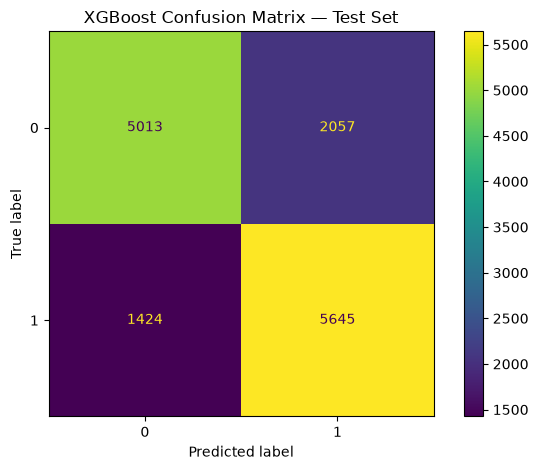

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
).plot()

plt.title("XGBoost Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

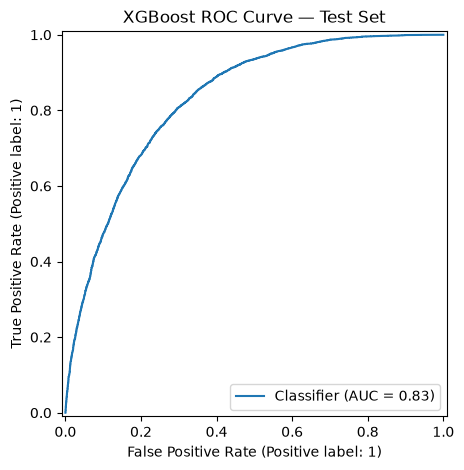

In [37]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("XGBoost ROC Curve — Test Set")
plt.tight_layout()
plt.show()

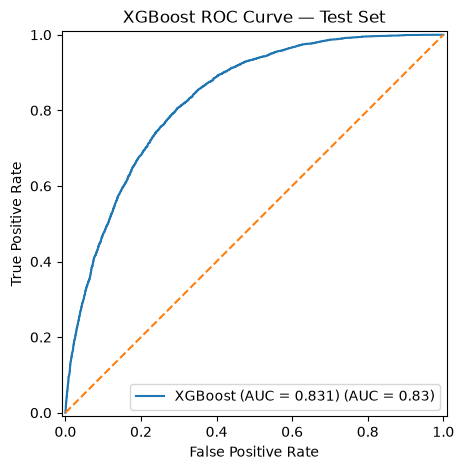

In [38]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name=f"XGBoost (AUC = {roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve — Test Set")
plt.tight_layout()
plt.show()

In [39]:
final_metrics

,Metric,Value
0,ROC-AUC,0.8310
1,Accuracy,0.7538
2,Precision,0.7329
3,Recall,0.7986
4,Specificity,0.7091
5,F1,0.7643


In [40]:
cv_test_comparison = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1"
    ],
    "CV_mean": [
        0.8313,
        0.7528,
        0.7324,
        0.7967,
        0.7089,
        0.7632
    ],
    "Test": [
        roc_auc,
        accuracy,
        precision,
        recall,
        specificity,
        f1
    ]
})

cv_test_comparison["Difference"] = (
    cv_test_comparison["Test"] -
    cv_test_comparison["CV_mean"]
)

cv_test_comparison.round(4)

,Metric,CV_mean,Test,Difference
0,ROC-AUC,0.8313,0.8310,-0.0003
1,Accuracy,0.7528,0.7538,0.0010
2,Precision,0.7324,0.7329,0.0005
3,Recall,0.7967,0.7986,0.0019
4,Specificity,0.7089,0.7091,0.0002
5,F1,0.7632,0.7643,0.0011


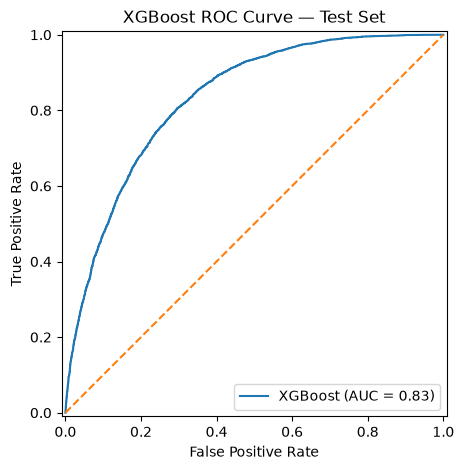

In [41]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="XGBoost"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve — Test Set")
plt.tight_layout()
plt.show()

In [ ]:
#####Modelling Summary. Four classifiers were developed under a common stratified five-fold cross-validation framework and tuned using training data only. XGBoost achieved the strongest overall development performance, with mean ROC-AUC of 0.8313, and was selected for final evaluation. On the untouched test set, it achieved ROC-AUC 0.8310, accuracy 0.7538, recall 0.7986, specificity 0.7091 and F1 0.7643. The close agreement between cross-validation and test results indicates stable generalisation, although the artificially balanced sample limits population-level interpretation of predictive values.